# **Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

file_path = r'C:\Users\pasha\OneDrive\Рабочий стол\11 практика\online_retail_II.csv'

data = pd.read_csv(file_path)

print('Размер данных:', data.shape)
print('\nСтолбцы:')
print(list(data.columns))

print('\nПервые строки:')
display(data.head())

print('\nПропуски:')
print(data.isna().sum())

data['Amount'] = data['Quantity'] * data['Price']

print('\nОбщая выручка:', data['Amount'].sum())
print('\nКоличество покупок:', data['Invoice'].nunique())
print('\nТоп товаров по выручке:')
print(data.groupby('Description')['Amount'].sum().sort_values(ascending=False).head(10))

print('\nЧастота покупок по клиентам:')
print(data['Customer ID'].value_counts().head(10))


Размер данных: (1067371, 8)

Столбцы:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Первые строки:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Пропуски:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Общая выручка: 19287250.56799999

Количество покупок: 53628

Топ товаров по выручке:
Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS                           84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: Amount, dtype: float64

Частота покупок по клиентам:
Customer ID
17841.0    13097
14911.0    11613
12748.0     7307
14606.0     6709
14096.0     5128
15311.0     4717
14156.0     4130
14646.0     3890
13089

#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [3]:
data = data.dropna(subset=['Customer ID'])

data['Invoice'] = data['Invoice'].astype(str)
data = data[~data['Invoice'].str.startswith('C')]
data = data[data['Quantity'] > 0]
data = data[data['Price'] > 0]

quantity_limit = data['Quantity'].quantile(0.99)
price_limit = data['Price'].quantile(0.99)
data = data[(data['Quantity'] <= quantity_limit) & (data['Price'] <= price_limit)]

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Amount', 'sum')
).reset_index()

rfm['avg_check'] = rfm['Monetary'] / rfm['Frequency']

print('Размер RFM:', rfm.shape)
display(rfm.head())

features = ['Recency', 'Frequency', 'Monetary', 'avg_check']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

print('Масштабирование выполнено с помощью StandardScaler.')


Размер RFM: (5778, 5)


,Customer ID,Recency,Frequency,Monetary,avg_check
0,12346.0,529,11,372.86,33.896364
1,12347.0,2,8,5383.72,672.965000
2,12348.0,75,5,1057.24,211.448000
3,12349.0,19,3,3418.19,1139.396667
4,12350.0,310,1,294.40,294.400000


Масштабирование выполнено с помощью StandardScaler.


#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

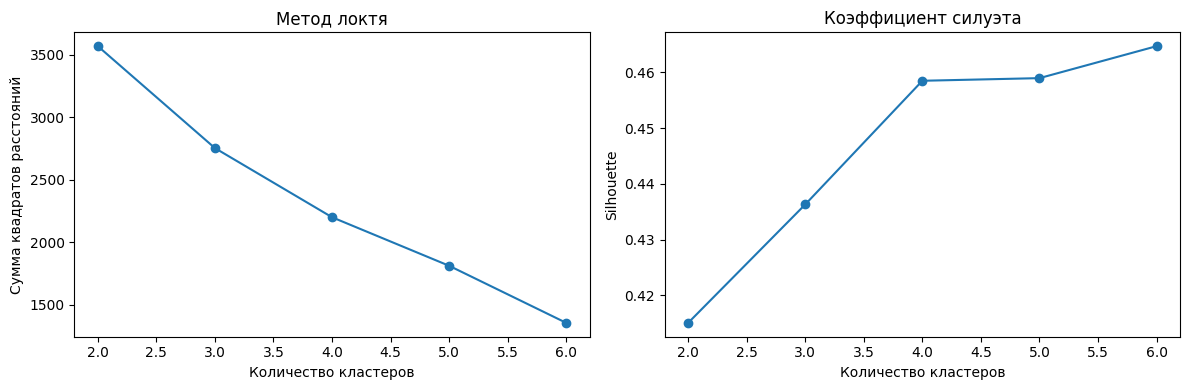

Выбранное число кластеров: 6

Количество кластеров:
KMeans 6
Hierarchical 6
DBSCAN 2
OPTICS 61


In [4]:
n_sample = min(1500, len(rfm_scaled))
sample_index = rfm.sample(n=n_sample, random_state=42).index
X_cluster = rfm_scaled[rfm.index.get_indexer(sample_index)]
rfm_cluster = rfm.loc[sample_index].copy()

k_values = range(2, 7)
inertia = []
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels_k = model.fit_predict(X_cluster)
    inertia.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_cluster, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertia, marker='o')
axes[0].set_title('Метод локтя')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Сумма квадратов расстояний')

axes[1].plot(list(k_values), silhouette_values, marker='o')
axes[1].set_title('Коэффициент силуэта')
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(silhouette_values))]
print('Выбранное число кластеров:', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42)
rfm_cluster['KMeans'] = kmeans.fit_predict(X_cluster)

hierarchical = AgglomerativeClustering(n_clusters=best_k)
rfm_cluster['Hierarchical'] = hierarchical.fit_predict(X_cluster)

dbscan = DBSCAN()
rfm_cluster['DBSCAN'] = dbscan.fit_predict(X_cluster)

optics = OPTICS()
rfm_cluster['OPTICS'] = optics.fit_predict(X_cluster)

print('\nКоличество кластеров:')
for col in ['KMeans', 'Hierarchical', 'DBSCAN', 'OPTICS']:
    print(col, rfm_cluster[col].nunique())


#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [5]:
def calculate_metrics(X, labels):
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return np.nan, np.nan, np.nan

    silhouette = silhouette_score(X_eval, labels_eval)
    db = davies_bouldin_score(X_eval, labels_eval)
    ch = calinski_harabasz_score(X_eval, labels_eval)
    return silhouette, db, ch

metrics = []

for name in ['KMeans', 'Hierarchical', 'DBSCAN', 'OPTICS']:
    labels = rfm_cluster[name].values
    silhouette, db, ch = calculate_metrics(X_cluster, labels)
    metrics.append([name, silhouette, db, ch])

metrics_df = pd.DataFrame(
    metrics,
    columns=['Алгоритм', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
)

display(metrics_df)

best_row = metrics_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print('Лучший результат по коэффициенту силуэта:', best_row['Алгоритм'])
print('Причина: у этого алгоритма самое высокое значение Silhouette среди полученных результатов.')
print('Истинных меток клиентов нет, поэтому ARI и NMI не рассчитываем.')


,Алгоритм,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.464717,0.790379,781.853035
1,Hierarchical,0.409030,0.861917,652.323698
2,DBSCAN,NaN,NaN,NaN
3,OPTICS,0.478284,0.663356,660.372740


Лучший результат по коэффициенту силуэта: OPTICS
Причина: у этого алгоритма самое высокое значение Silhouette среди полученных результатов.
Истинных меток клиентов нет, поэтому ARI и NMI не рассчитываем.


#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

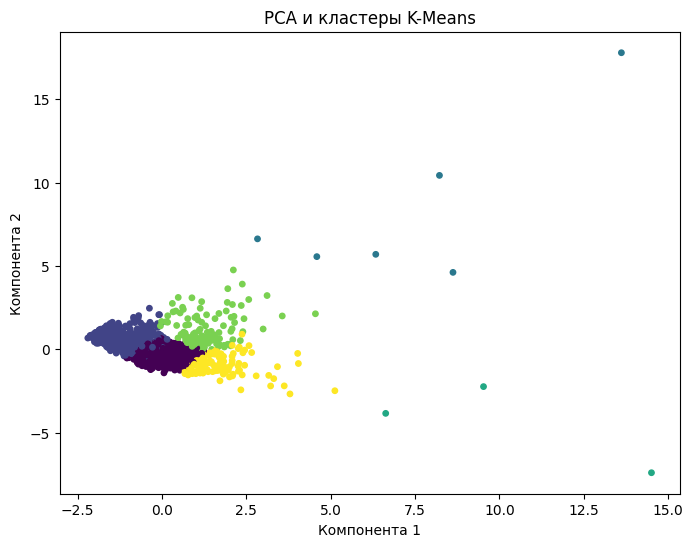

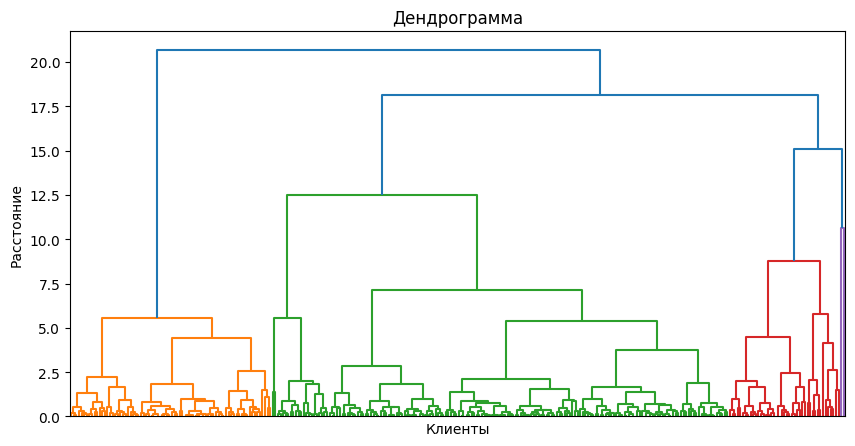

,Recency,Frequency,Monetary,avg_check
KMeans,,,,
0,77.724093,4.967617,1305.947903,258.247186
1,470.536017,2.260593,541.646890,239.688967
2,187.500000,4.666667,13929.538333,3701.175616
3,4.333333,127.000000,78232.374000,670.332584
4,125.853846,4.776923,3795.105931,837.914702
5,28.700855,25.170940,9507.993171,391.731994


,Recency,Frequency,Monetary,avg_check,Сегмент
KMeans,,,,,
0,77.724093,4.967617,1305.947903,258.247186,Обычные клиенты
1,470.536017,2.260593,541.646890,239.688967,Клиенты со сниженной активностью
2,187.500000,4.666667,13929.538333,3701.175616,Клиенты со сниженной активностью
3,4.333333,127.000000,78232.374000,670.332584,Лояльные клиенты
4,125.853846,4.776923,3795.105931,837.914702,Клиенты со сниженной активностью
5,28.700855,25.170940,9507.993171,391.731994,Лояльные клиенты


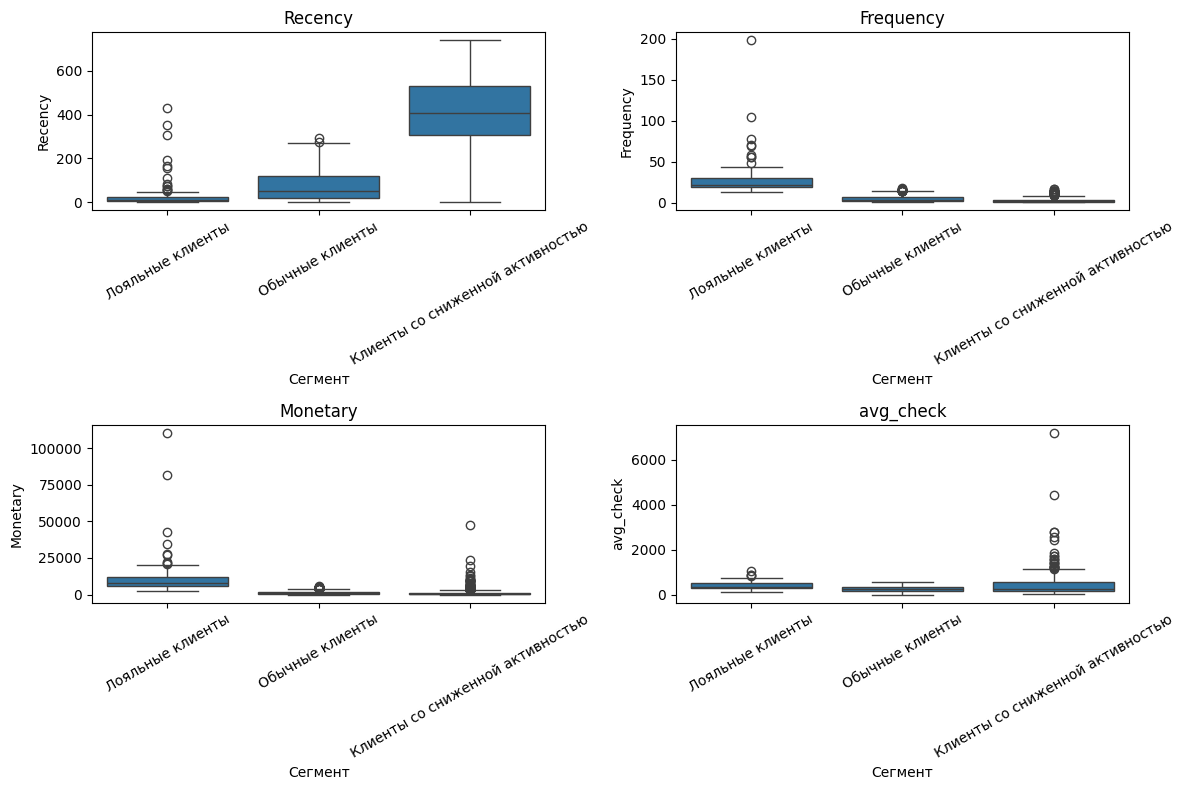

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm_cluster['KMeans'], s=15)
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.title('PCA и кластеры K-Means')
plt.show()

link = linkage(X_cluster[:300], method='ward')
plt.figure(figsize=(10, 5))
dendrogram(link, no_labels=True)
plt.title('Дендрограмма')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.show()

cluster_summary = rfm_cluster.groupby('KMeans')[features].mean()
display(cluster_summary)

recency_med = cluster_summary['Recency'].median()
frequency_med = cluster_summary['Frequency'].median()
monetary_med = cluster_summary['Monetary'].median()

segment_names = {}
for cluster, row in cluster_summary.iterrows():
    if row['Recency'] <= recency_med and row['Frequency'] >= frequency_med and row['Monetary'] >= monetary_med:
        segment_names[cluster] = 'Лояльные клиенты'
    elif row['Recency'] > recency_med:
        segment_names[cluster] = 'Клиенты со сниженной активностью'
    elif row['Monetary'] >= monetary_med:
        segment_names[cluster] = 'Клиенты с крупными покупками'
    else:
        segment_names[cluster] = 'Обычные клиенты'

cluster_summary['Сегмент'] = cluster_summary.index.map(segment_names)
display(cluster_summary)

rfm_plot = rfm_cluster.copy()
rfm_plot['Сегмент'] = rfm_plot['KMeans'].map(segment_names)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=rfm_plot, x='Сегмент', y=feature, ax=ax)
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(feature)
plt.tight_layout()
plt.show()


#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

# **ВАШ ОТВЕТ**

По результатам кластеризации клиентов можно разделить на несколько сегментов по давности покупок, частоте покупок и общей сумме покупок

Лояльные клиенты. Для этой группы можно использовать программы лояльности и персональные предложения, чтобы сохранить активность

Клиенты со сниженной активностью. Им можно отправлять персональные скидки и напоминания о товарах, чтобы вернуть их к покупкам

Клиенты с крупными покупками. Для них можно предлагать дополнительные товары и персональные предложения с учётом их покупательского поведения

Обычные клиенты. Для этой группы можно использовать общие акции и предложения, которые могут увеличить частоту покупок

Такое разделение поможет делать предложения более подходящими для разных групп клиентов и может увеличить частоту покупок и выручку

#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Описание цели работы и её значимости для бизнеса.
- **Методология:**
  - Подробное описание проведенных шагов.
- **Результаты:**
  - Представление метрик оценки и визуализаций.
  - Описание сегментов клиентов.
- **Обсуждение:**
  - Анализ полученных результатов.
  - Сравнение алгоритмов и обоснование выбора.
- **Рекомендации:**
  - Предложения по внедрению результатов в бизнес-процессы.
- **Заключение:**
  - Выводы о проделанной работе и её значимости.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.

